<a href="https://colab.research.google.com/github/maciekpopik/ENEN-645-Group-4-Final/blob/main/PlantLab2RealGeneralization_CutMix%2BGradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EfficientNet Training with CutMix and Grad-CAM

This notebook trains an ImageNet-pretrained EfficientNet-B0 on the plant disease dataset using CutMix augmentation, then evaluates both the in-distribution and out-of-distribution splits. After the main training stage, a short few-shot adaptation step is performed on the `Few_Shot` set and Grad-CAM heatmaps are generated to compare model attention on `Test_ID` and `Test_OOD` images.

First, the required libraries are imported and the runtime setup is defined.  
This startup section follows the same local / Kaggle / Google Drive structure as the `CustomModel_Aug_08` notebook so the same notebook can be used on a Windows machine or in Colab.

The full dataset was uploaded to Kaggle and can be accessed here if you want to run this in Colab using the Kaggle option:  
https://www.kaggle.com/datasets/maciekpopik/plantlab2realgeneralization

In [ ]:
# Imports and Setup
import os
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

# Methods to obtain data
# DATA_PATH is the default local directory for data if other methods fail.
# USE_KAGGLE downloads the data from Kaggle.
# USE_DRIVE is mainly intended for Colab and mounts Google Drive.
DATA_PATH = r"C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset"
USE_KAGGLE = False
USE_DRIVE = False

cuda:0


A small helper function is used to detect whether the notebook is running in Colab.  
This is mainly used so Colab-only setup steps are skipped on a local Windows notebook.

In [ ]:
# Helper function to check if code is being run on Colab
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

def ensure_package(package_name):
    try:
        __import__(package_name)
    except ImportError:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

Depending on the selected option above, the dataset is either downloaded from Kaggle, mounted from Drive, or read directly from the local folder.  
The final dataset root is stored in `OUTDIR` so the rest of the notebook can stay unchanged across platforms.

In [ ]:
# Logic for importing data based on Kaggle, Google Drive and local directory settings
if USE_KAGGLE:
    ensure_package("kagglehub")
    import kagglehub

    KAGGLE_HANDLE = "maciekpopik/plantlab2realgeneralization"

    dataset_path = kagglehub.dataset_download(KAGGLE_HANDLE)
    dataset_path = Path(dataset_path)

    if is_colab():
        TARGET_DIR = Path("/content/plant_dataset")

        if TARGET_DIR.exists():
            shutil.rmtree(TARGET_DIR)

        shutil.copytree(dataset_path, TARGET_DIR)
        OUTDIR = str(TARGET_DIR)
    else:
        TARGET_DIR = Path(DATA_PATH)

        if not TARGET_DIR.exists():
            shutil.copytree(dataset_path, TARGET_DIR)

        OUTDIR = str(TARGET_DIR)

    print("Dataset ready at:", OUTDIR)

elif USE_DRIVE and is_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    OUTDIR = "/content/drive/MyDrive/ENEN-645/PlantLab2RealGeneralization"  # Change if needed
    print("Dataset ready at:", OUTDIR)

else:
    OUTDIR = DATA_PATH
    print("Using local dataset at:", OUTDIR)

Using local dataset at: C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset


The dataset paths are now defined for the training, validation, in-distribution test, few-shot, and out-of-distribution test folders.  
These match the split structure used in the rest of your project notebooks.

In [ ]:
# === Directory setup ===
train_dir    = os.path.join(OUTDIR, "Train")
val_dir      = os.path.join(OUTDIR, "Val")
test_id_dir  = os.path.join(OUTDIR, "Test_ID")
few_shot_dir = os.path.join(OUTDIR, "Few_Shot")
test_ood_dir = os.path.join(OUTDIR, "Test_OOD")

print("Train   :", train_dir)
print("Val     :", val_dir)
print("Test ID :", test_id_dir)
print("Few Shot:", few_shot_dir)
print("Test OOD:", test_ood_dir)

Train   : C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset\Train
Val     : C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset\Val
Test ID : C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset\Test_ID
Few Shot: C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset\Few_Shot
Test OOD: C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset\Test_OOD


Next, the main hyperparameters are defined.  
`NUM_WORKERS` is reduced to `0` on Windows for notebook portability, while non-Windows environments can still use worker processes for faster loading.

In [ ]:
# Parameters
IMG_SIZE = 224
BATCH_SIZE = 32 if is_colab() else 128
EPOCHS = 25
FEWSHOT_EPOCHS = 5
LR = 3e-4
NUM_WORKERS = 0 if os.name == "nt" else 2

PIN_MEMORY = torch.cuda.is_available()

NORM_MEAN = [0.4689, 0.4986, 0.4264] # Mean from created dataset (calculated in the other notebooks of project)
# ImageNet mean for comparison: [0.485, 0.456, 0.406]
NORM_STD  = [0.1997, 0.1730, 0.2131] # Std from created dataset (calculated in the other notebooks of project)
# ImageNet std for comparison: [0.229, 0.224, 0.225]

CHECKPOINT_DIR = os.path.join(os.getcwd(), "checkpoints_cutmix_gradcam")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model_cutmix_gradcam.pth")
FEWSHOT_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model_cutmix_gradcam_fewshot.pth")

print("Checkpoint path:", BEST_MODEL_PATH)

Checkpoint path: c:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\checkpoints_cutmix_gradcam\best_model_cutmix_gradcam.pth


The image transforms are defined here.  
CutMix is applied later during training, while these transforms handle the usual resizing, cropping, augmentation, and normalization steps for EfficientNet.

In [ ]:
# Data transforms
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(0.3, 0.35, 0.4, 0.08),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

The datasets are loaded using `ImageFolder`, and data loaders are created for each split.  
The class names and class-to-index mapping are taken from the training set and assumed to match across `Val`, `Test_ID`, `Few_Shot`, and `Test_OOD`.

In [ ]:
# Dataset loading and data loaders
pv_train = datasets.ImageFolder(train_dir, train_transforms)
pv_val   = datasets.ImageFolder(val_dir, eval_transforms)
pv_test  = datasets.ImageFolder(test_id_dir, eval_transforms)

pd_few   = datasets.ImageFolder(few_shot_dir, train_transforms)
pd_test  = datasets.ImageFolder(test_ood_dir, eval_transforms)

loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True

train_loader   = DataLoader(pv_train, shuffle=True,  **loader_kwargs)
val_loader     = DataLoader(pv_val,   shuffle=False, **loader_kwargs)
pv_test_loader = DataLoader(pv_test,  shuffle=False, **loader_kwargs)
pd_few_loader  = DataLoader(pd_few,   shuffle=True,  **loader_kwargs)
pd_test_loader = DataLoader(pd_test,  shuffle=False, **loader_kwargs)

NUM_CLASSES = len(pv_train.classes)
class_names = pv_train.classes

print("Number of classes:", NUM_CLASSES)
print("Sample classes:", class_names[:5])

Number of classes: 30
Sample classes: ['Apple___Apple_scab', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy']


An EfficientNet-B0 backbone pretrained on ImageNet is used as the base model.  
The final classifier layer is replaced so the network predicts the number of classes in the plant dataset.

In [ ]:
# Model setup
model = models.efficientnet_b0(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=30, bias=True)
)


Class imbalance is handled here by computing class counts from the PlantVillage training split and converting them into inverse-frequency class weights.  
These weights are passed to `CrossEntropyLoss` so that underrepresented classes contribute more strongly to the training loss.

Additionally, AdamW is used for training the model weights.

In [ ]:
# Optimizer and weighted loss

# If your training dataset variable is named something else, replace `pv_train` below.
train_dataset_for_weights = pv_train

# Count samples per class from the training split
class_counts = torch.bincount(
    torch.tensor(train_dataset_for_weights.targets, dtype=torch.long),
    minlength=len(train_dataset_for_weights.classes)
).float()

# Inverse-frequency weights, normalized to have mean = 1
class_weights = class_counts.sum() / (len(class_counts) * class_counts)
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(device)

# Optional: print counts and weights for inspection
print("Class counts:")
for cls_name, count in zip(train_dataset_for_weights.classes, class_counts.tolist()):
    print(f"  {cls_name}: {int(count)}")

print("\nClass weights:")
for cls_name, weight in zip(train_dataset_for_weights.classes, class_weights.tolist()):
    print(f"  {cls_name}: {weight:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR)

Class counts:
  Apple___Apple_scab: 441
  Apple___Cedar_apple_rust: 193
  Apple___healthy: 1151
  Blueberry___healthy: 1052
  Cherry___healthy: 598
  Corn_(maize)___healthy: 814
  Corn___Cercospora_leaf_spot: 359
  Corn___Common_rust: 834
  Corn___Northern_Leaf_Blight: 689
  Grape___Black_rot: 826
  Grape___Esca_(Black_Measles): 968
  Grape___healthy: 296
  Peach___healthy: 252
  Pepper,_bell___Bacterial_spot: 698
  Pepper,_bell___healthy: 1034
  Potato___Early_blight: 700
  Potato___Late_blight: 700
  Potato___healthy: 106
  Raspberry___healthy: 260
  Soybean___healthy: 3563
  Squash___Powdery_mildew: 1285
  Strawberry___healthy: 319
  Tomato___Bacterial_spot: 1489
  Tomato___Early_blight: 700
  Tomato___Late_blight: 1336
  Tomato___Leaf_Mold: 666
  Tomato___Septoria_leaf_spot: 1240
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 3750
  Tomato___Tomato_mosaic_virus: 261
  Tomato___healthy: 1114

Class weights:
  Apple___Apple_scab: 1.1323
  Apple___Cedar_apple_rust: 2.5873
  Apple___healthy

The next two helper functions implement CutMix.  
A random patch from one image is inserted into another image in the batch, and the loss is blended according to how much of each image remains.

In [ ]:
# CutMix helpers
def cutmix_data(x, y, alpha=1.0):
    x = x.clone()

    lam = np.random.beta(alpha, alpha)

    batch_size, _, H, W = x.size()
    index = torch.randperm(batch_size, device=x.device)

    cut_ratio = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_ratio)
    cut_h = int(H * cut_ratio)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]

    lam = 1.0 - ((x2 - x1) * (y2 - y1) / (W * H))

    return x, y, y[index], lam

def cutmix_loss(pred, y1, y2, lam):
    return lam * criterion(pred, y1) + (1.0 - lam) * criterion(pred, y2)

These helper functions handle the training and evaluation loops.  
During the main training stage, CutMix is applied with 50% probability, while evaluation uses the usual top-1 prediction accuracy.

In [ ]:
# Training and evaluation helpers
def train_epoch(loader, optimizer, cutmix=True):
    model.train()

    running_loss = 0.0
    total_samples = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        if cutmix and np.random.rand() < 0.5:
            x, y1, y2, lam = cutmix_data(x, y)
            pred = model(x)
            loss = cutmix_loss(pred, y1, y2, lam)
        else:
            pred = model(x)
            loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    return running_loss / max(total_samples, 1)

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / max(total, 1)

The model is first trained on the PlantVillage training split and monitored using the validation split.  
Whenever validation accuracy improves, the best weights are saved to disk for later evaluation.

In [ ]:
# Training on PlantVillage
best_val = 0.0

for e in range(EPOCHS):
    train_loss = train_epoch(train_loader, optimizer, cutmix=True)
    val_acc = evaluate(val_loader)

    print(f"Epoch {e+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("  Saved new best model.")

Epoch 01/25 | Train Loss: 1.1254 | Val Acc: 0.9702
  Saved new best model.


Epoch 02/25 | Train Loss: 0.6042 | Val Acc: 0.9842
  Saved new best model.


Epoch 03/25 | Train Loss: 0.5110 | Val Acc: 0.9832


Epoch 04/25 | Train Loss: 0.4568 | Val Acc: 0.9860
  Saved new best model.


Epoch 05/25 | Train Loss: 0.4454 | Val Acc: 0.9896
  Saved new best model.


...

Epoch 21/25 | Train Loss: 0.3298 | Val Acc: 0.9963


Epoch 22/25 | Train Loss: 0.2885 | Val Acc: 0.9968
  Saved new best model.


Epoch 23/25 | Train Loss: 0.3094 | Val Acc: 0.9938


Epoch 24/25 | Train Loss: 0.3240 | Val Acc: 0.9924


Epoch 25/25 | Train Loss: 0.3693 | Val Acc: 0.9971
  Saved new best model.


After training, the best checkpoint is reloaded and the baseline model is evaluated on the validation, in-distribution `Test_ID`, and out-of-distribution `Test_OOD` splits before any few-shot fine-tuning is performed.  

In [ ]:
# =========================
# BASELINE EVALUATION ON TEST_OOD (BEFORE FEW-SHOT)
# =========================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

val_acc = evaluate(val_loader)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

pv_test_acc = evaluate(pv_test_loader)
print(f"PlantVillage Test_ID Accuracy (before few-shot): {pv_test_acc * 100:.2f}%")

pd_test_acc = evaluate(pd_test_loader)
print(f"PlantDoc Test_OOD Accuracy (before few-shot): {pd_test_acc * 100:.2f}%")


Validation Accuracy: 99.71%
PlantVillage Test_ID Accuracy (before few-shot): 99.76%
PlantDoc Test_OOD Accuracy (before few-shot): 23.88%


A short few-shot adaptation step is now performed using the `Few_Shot` set.  
The feature extractor is frozen and only the classifier head is updated so the model can adapt slightly to field-style images without fully retraining the backbone.

In [ ]:
# Few-shot adaptation on PlantDoc-style images
for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

for e in range(FEWSHOT_EPOCHS):
    fs_loss = train_epoch(pd_few_loader, optimizer, cutmix=False)
    print(f"Few-shot Epoch {e+1:02d}/{FEWSHOT_EPOCHS} | Train Loss: {fs_loss:.4f}")

torch.save(model.state_dict(), FEWSHOT_MODEL_PATH)
print("Saved few-shot model to:", FEWSHOT_MODEL_PATH)

Few-shot Epoch 01/5 | Train Loss: 3.6599


Few-shot Epoch 02/5 | Train Loss: 3.9959


Few-shot Epoch 03/5 | Train Loss: 3.7104


Few-shot Epoch 04/5 | Train Loss: 3.5547


Few-shot Epoch 05/5 | Train Loss: 3.5200
Saved few-shot model to: c:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\checkpoints_cutmix_gradcam\best_model_cutmix_gradcam_fewshot.pth


The adapted model is now evaluated again on the validation, in-distribution `Test_ID`, and out-of-distribution `Test_OOD` splits.  
This shows whether few-shot tuning improves OOD accuracy and whether that improvement comes with any tradeoff on the original PlantVillage-style data.

In [ ]:
# Final evaluation after few-shot
val_acc_after = evaluate(val_loader)
pv_test_acc_after = evaluate(pv_test_loader)
pd_test_acc_after = evaluate(pd_test_loader)

pv_change = (pv_test_acc_after - pv_test_acc) * 100
pd_change = (pd_test_acc_after - pd_test_acc) * 100

print(f"Validation Accuracy (after few-shot): {val_acc_after * 100:.2f}%")
print(f"PlantVillage Test_ID Accuracy (after few-shot): {pv_test_acc_after * 100:.2f}%")
print(f"PlantDoc Test_OOD Accuracy (after few-shot): {pd_test_acc_after * 100:.2f}%")
print()
print(f"PlantVillage Test_ID Accuracy change: {pv_test_acc * 100:.2f}% -> {pv_test_acc_after * 100:.2f}% ({pv_change:+.2f} pp)")
print(f"PlantDoc Test_OOD Accuracy change: {pd_test_acc * 100:.2f}% -> {pd_test_acc_after * 100:.2f}% ({pd_change:+.2f} pp)")
print()

Validation Accuracy (after few-shot): 98.01%
PlantVillage Test_ID Accuracy (after few-shot): 98.08%
PlantDoc Test_OOD Accuracy (after few-shot): 28.26%

PlantVillage Test_ID Accuracy change: 99.76% -> 98.08% (-1.69 pp)
PlantDoc Test_OOD Accuracy change: 23.88% -> 28.26% (+4.38 pp)



In [ ]:
# Re-enable gradients for Grad-CAM after few-shot froze the backbone
for param in model.parameters():
    param.requires_grad = True

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

The following helper class captures activations and gradients from an EfficientNet feature layer and produces a Grad-CAM map that will later be overlaid on the original image.  

In [ ]:
# =========================
# GRAD-CAM
# =========================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, inputs, output):
        self.activations = output
        if output.requires_grad:
            output.retain_grad()

    def generate(self, image_tensor, target_class=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        image_tensor = image_tensor.unsqueeze(0).to(device) if image_tensor.dim() == 3 else image_tensor.to(device)

        with torch.enable_grad():
            output = self.model(image_tensor)

            if target_class is None:
                target_class = output.argmax(dim=1).item()

            score = output[:, target_class].sum()
            score.backward()

        gradients = self.activations.grad
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(
            cam,
            size=(IMG_SIZE, IMG_SIZE),
            mode="bilinear",
            align_corners=False,
        )

        cam = cam[0, 0].detach().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        probs = torch.softmax(output, dim=1)
        pred_idx = output.argmax(dim=1).item()
        pred_conf = probs[0, pred_idx].item()

        return cam, pred_idx, pred_conf

    def remove(self):
        self.handle.remove()


target_layer = model.features[5]
gradcam = GradCAM(model, target_layer)

In [ ]:
# =========================
# GRAD-CAM VISUALIZATION HELPERS
# =========================

IMAGENET_MEAN = torch.tensor(NORM_MEAN).view(3, 1, 1)
IMAGENET_STD  = torch.tensor(NORM_STD).view(3, 1, 1)

def denormalize_image(image_tensor):
    img = image_tensor.detach().cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = img.permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

def build_overlay(img, cam, alpha=0.30):
    heatmap = (255 * cam).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    overlay = (1 - alpha) * img + alpha * heatmap
    return np.clip(overlay, 0, 1)

@torch.no_grad()
def collect_candidate_examples(loader, max_batches=8):
    model.eval()
    candidates = []

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        confs, preds = probs.max(dim=1)

        for i in range(images.size(0)):
            candidates.append({
                "image": images[i].detach().cpu(),
                "label": labels[i].item(),
                "pred": preds[i].item(),
                "conf": confs[i].item(),
                "correct": preds[i].item() == labels[i].item(),
            })

        if batch_idx + 1 >= max_batches:
            break

    return candidates

def select_best_example(loader, prefer_correct=True, max_batches=8):
    candidates = collect_candidate_examples(loader, max_batches=max_batches)

    if not candidates:
        raise RuntimeError("No examples found in loader.")

    if prefer_correct:
        correct = [c for c in candidates if c["correct"]]
        if correct:
            return max(correct, key=lambda c: c["conf"])

    return max(candidates, key=lambda c: c["conf"])

def compare_plantvillage_vs_plantdoc_gradcam(plantvillage_loader, plantdoc_loader, prefer_correct=True):
    pv_example = select_best_example(plantvillage_loader, prefer_correct=prefer_correct)
    pd_example = select_best_example(plantdoc_loader, prefer_correct=prefer_correct)

    pv_img = denormalize_image(pv_example["image"])
    pv_cam, pv_pred, pv_conf = gradcam.generate(pv_example["image"].unsqueeze(0).to(device))
    pv_overlay = build_overlay(pv_img, pv_cam, alpha=0.30)

    pd_img = denormalize_image(pd_example["image"])
    pd_cam, pd_pred, pd_conf = gradcam.generate(pd_example["image"].unsqueeze(0).to(device))
    pd_overlay = build_overlay(pd_img, pd_cam, alpha=0.30)

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0, 0].imshow(pv_img)
    axes[0, 0].set_title(f"PlantVillage image\nTrue: {class_names[pv_example['label']]}")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(pv_overlay)
    axes[0, 1].set_title(f"PlantVillage Grad-CAM overlay\nPred: {class_names[pv_pred]} ({pv_conf:.2%})")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(pd_img)
    axes[1, 0].set_title(f"PlantDoc image\nTrue: {class_names[pd_example['label']]}")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(pd_overlay)
    axes[1, 1].set_title(f"PlantDoc Grad-CAM overlay\nPred: {class_names[pd_pred]} ({pd_conf:.2%})")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


The examples shown below are selected automatically from `Test_ID` and `Test_OOD`.  
Because the selection is confidence-based, the Grad-CAM visualizations should be interpreted as illustrative examples rather than a full summary of model behavior.

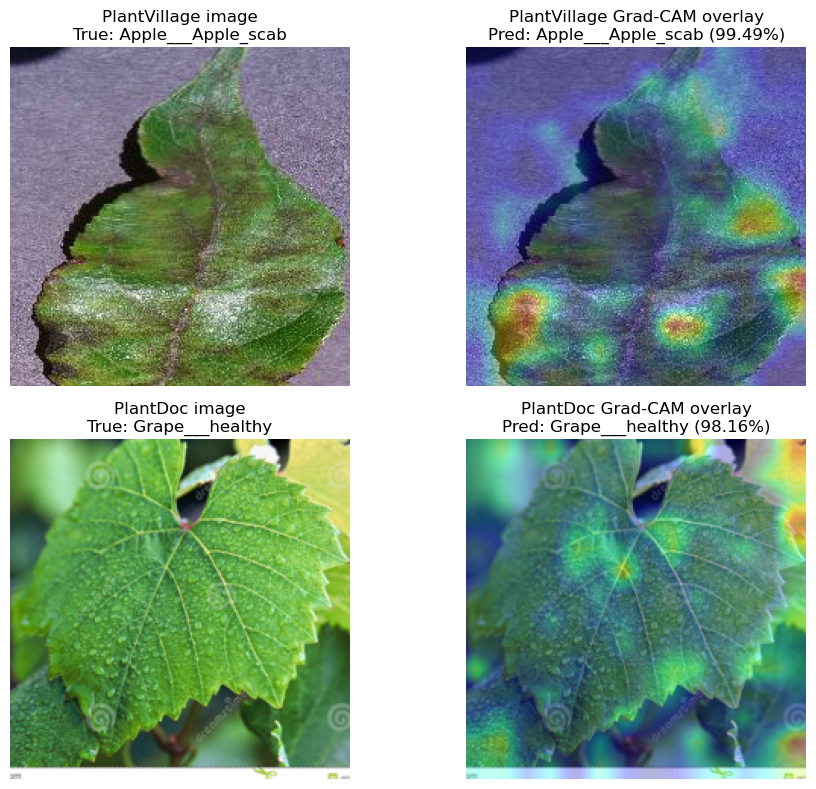

In [ ]:
# Compare clean overlays for one PlantVillage and one PlantDoc example
compare_plantvillage_vs_plantdoc_gradcam(
    plantvillage_loader=pv_test_loader,
    plantdoc_loader=pd_test_loader,
    prefer_correct=True,
)


In [ ]:
# Cleanup when finished with Grad-CAM
gradcam.remove()
